# IMDB Sentiment Analysis

In [99]:
import nltk
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('wordnet') 
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sanasalim/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
imdb = pd.read_csv("/Users/sanasalim/Downloads/Linkific/Day 9/IMDB Dataset.csv")

In [8]:
imdb.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
imdb.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [38]:
imdb.describe()

,review,sentiment,cleaned
count,50000,50000,50000
unique,49582,2,49580
top,Loved today's show!!! It was a variety and not...,positive,loved today s show it was a variety and not...
freq,5,25000,5


In [39]:
imdb['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [29]:
lemmatizer = WordNetLemmatizer()

In [60]:
def clean_text(text):
    # make everything lowercase
    text = text.lower()
    # remove trailing and leading whitespace
    text = text.strip()
    # remove extra whitespace
    text = re.sub(r"\s+"," ",text)
    # remove html tags
    text = re.sub("<.*?>", "", text) 
    # remove special characters
    text = re.sub("[^a-zA-Z]", " ", text)   
    return text

In [73]:
def clean_text(text):
    # make everything lowercase
    text = text.lower()
    # remove trailing and leading whitespace
    text = text.strip()
    # remove extra whitespace
    text = re.sub(r"\s+"," ",text)
    # remove html tags
    text = re.sub("<.*?>", "", text) 
    # remove special characters
    text = re.sub("[^a-zA-Z]", " ", text)   
    # tokenise  
    tokens = word_tokenize(text)
    # remove stopwords
    sw = set(stopwords.words('english'))
    removed = []
    for word in tokens:
        if word not in sw:
            removed.append(word)
    # lemmatize
    lemmatized = []
    for word in removed:
        lemmatized.append(lemmatizer.lemmatize(word,pos="v"))
    tokens = " ".join(lemmatized)
    return tokens

In [61]:
imdb["cleaned"] = imdb["review"].apply(clean_text)

In [36]:
imdb.head()

,review,sentiment,cleaned
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...


In [37]:
imdb.loc[1]

review       A wonderful little production. <br /><br />The...
sentiment                                             positive
cleaned      a wonderful little production  the filming tec...
Name: 1, dtype: object

In [4]:
imdb["sentiment"] = imdb["sentiment"].map({
    "negative": 0,
    "positive": 1})
imdb.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [74]:
imdb["cleaned"] = imdb["review"].apply(clean_text)
imdb.head()

,review,sentiment,cleaned
0,One of the other reviewers has mentioned that ...,1,one reviewers mention watch oz episode hook ri...
1,A wonderful little production. <br /><br />The...,1,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,1,think wonderful way spend time hot summer week...
3,Basically there's a family where a little boy ...,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stun fi...


In [46]:
imdb["cleaned"]

0        one reviewers mention watch oz episode hook ri...
1        wonderful little production film technique una...
2        think wonderful way spend time hot summer week...
3        basically family little boy jake think zombie ...
4        petter mattei love time money visually stun fi...
                               ...                        
49995    think movie right good job creative original f...
49996    bad plot bad dialogue bad act idiotic direct a...
49997    catholic teach parochial elementary school nun...
49998    go disagree previous comment side maltin one s...
49999    one expect star trek movies high art fan expec...
Name: cleaned, Length: 50000, dtype: object

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english",max_features=5000)
X = vectorizer.fit_transform(imdb["cleaned"])
y = imdb["sentiment"]

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42,stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [91]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred)
print("Precision:",precision.round(4))
recall = recall_score(y_test, y_pred)
print("Recall:",recall.round(4))
f1 = f1_score(y_test, y_pred)
print("f1 score:",f1.round(4))
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(cv_scores)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Accuracy: 0.8872
Precision: 0.8775
Recall: 0.9
f1 score: 0.8886
[0.8855 0.8833 0.8817 0.8814 0.882 ]
              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



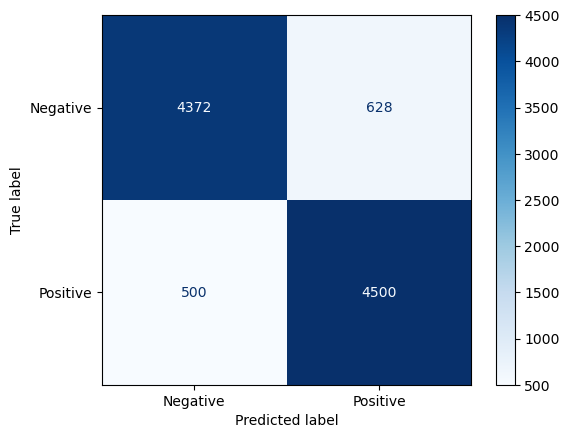

In [100]:
cm = confusion_matrix(y_test,y_pred)
tn, fp, fn, tp = cm.ravel()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [104]:
print(tp,tn,fp,fn)

4500 4372 628 500


In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm,annot=True,cmap="Blues",xticklabels=["Died", "Survived"],yticklabels=["Died", "Survived"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [85]:
reviews = ["This was a great movie!", "I hated this movie and thought it was awful", "I am not really eager to see the next movie in the franchise","It was a thrilling addition to the series"]
for review in reviews:    
    clean_review = clean_text(review)
    review_vector = vectorizer.transform([clean_review])
    prediction = model.predict(review_vector)[0]
    if prediction == 1:
        print("Positive:",review)
    else:
        print("Negative:",review)
    prob = model.predict_proba(review_vector)[0]
    print("\nNegative:", prob[0])
    print("Positive:", prob[1])
    print("\n\n")

Positive: This was a great movie!

Negative: 0.002838460404818166
Positive: 0.9971615395951818



Negative: I hated this movie and thought it was awful

Negative: 0.9936044006773762
Positive: 0.006395599322623821



Negative: I am not really eager to see the next movie in the franchise

Negative: 0.7365548316479089
Positive: 0.26344516835209103



Positive: It was a thrilling addition to the series

Negative: 0.17714075232028348
Positive: 0.8228592476797165





In [105]:
import joblib
joblib.dump(model, "imdb_sentiment_model.pkl")
joblib.dump(vectorizer, "imdb_vectorizer.pkl")

['imdb_vectorizer.pkl']